**Setup & Data Loading**

In [ ]:
import numpy as np
import random
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from scipy import stats

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Input, Dense, Conv2D, Flatten, Concatenate, Dropout, BatchNormalization, GlobalAveragePooling2D, Multiply, Reshape, Add, RandomFlip, Layer
from keras.regularizers import l2
from keras.models import Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("📦 ĐANG TẢI DỮ LIỆU ĐA PHƯƠNG THỨC...")
SAVE_DIR = '/content/drive/MyDrive/SmartSite/Step 3: Spatial_Grid/'

# 1. Load Data
df_tab = pd.read_csv(SAVE_DIR + 'Spatial_Grid_Tabular.csv')
tensors = np.load(SAVE_DIR + 'Spatial_Tensors.npz')

📦 ĐANG TẢI DỮ LIỆU ĐA PHƯƠNG THỨC...


In [ ]:
print("=" * 60)
print("1. TỔNG QUAN df_tab (TABULAR DATA)")
print("=" * 60)
print(f"Shape: {df_tab.shape} — {df_tab.shape[0]} ô lưới, {df_tab.shape[1]} cột")
print(f"\nCác cột hiện có:")
for col in df_tab.columns:
    print(f"  - {col}: {df_tab[col].dtype} | null: {df_tab[col].isnull().sum()} | unique: {df_tab[col].nunique()}")

print("\n--- Mẫu 5 dòng đầu ---")
display(df_tab.head())

print("\n--- Thống kê mô tả ---")
display(df_tab.describe())

print("\n" + "=" * 60)
print("2. PHÂN TÍCH CÁC CỘT QUAN TRỌNG")
print("=" * 60)

# City distribution
if 'City' in df_tab.columns:
    print("\nPhân bố theo thành phố:")
    print(df_tab['City'].value_counts())

# Cafe_Count distribution
if 'Cafe_Count' in df_tab.columns:
    print(f"\nCafe_Count:")
    print(f"  Ô có quán (> 0): {(df_tab['Cafe_Count'] > 0).sum()} / {len(df_tab)} ({(df_tab['Cafe_Count'] > 0).mean()*100:.1f}%)")
    print(f"  Ô không có quán: {(df_tab['Cafe_Count'] == 0).sum()}")
    print(f"  Min/Max/Mean: {df_tab['Cafe_Count'].min()} / {df_tab['Cafe_Count'].max()} / {df_tab['Cafe_Count'].mean():.2f}")

print("\n" + "=" * 60)
print("3. SPATIAL TENSORS (ẢNH 11x11)")
print("=" * 60)
tensor_keys = list(tensors.keys())
print(f"Số lượng tensor (grid): {len(tensor_keys)}")
sample_key = tensor_keys[0]
sample_tensor = tensors[sample_key]
print(f"Key mẫu: '{sample_key}'  |  Shape: {sample_tensor.shape}  |  dtype: {sample_tensor.dtype}")
print(f"Giá trị min/max toàn bộ: {sample_tensor.min():.4f} / {sample_tensor.max():.4f}")
print(f"\nThống kê từng channel (của tensor mẫu '{sample_key}'):")
channel_names = ['POI_Ch0', 'POI_Ch1', 'POI_Ch2', 'POI_Ch3', 'POI_Ch4']  # đổi nếu bà biết tên thật
for i in range(sample_tensor.shape[-1]):
    ch = sample_tensor[:, :, i]
    print(f"  Channel {i} ({channel_names[i] if i < len(channel_names) else ''}):"
          f"  min={ch.min():.3f}  max={ch.max():.3f}  mean={ch.mean():.3f}  nonzero={np.count_nonzero(ch)}/121")

print("\n" + "=" * 60)
print("4. KIỂM TRA KHỚP GIỮA TABULAR VÀ TENSOR")
print("=" * 60)
if 'Grid_ID' in df_tab.columns:
    tab_ids  = set(df_tab['Grid_ID'].astype(str))
    tens_ids = set(str(k) for k in tensor_keys)
    print(f"Grid_ID trong tabular : {len(tab_ids)}")
    print(f"Key trong tensor      : {len(tens_ids)}")
    print(f"Khớp nhau             : {len(tab_ids & tens_ids)}")
    print(f"Trong tabular nhưng thiếu tensor: {len(tab_ids - tens_ids)}")
    print(f"Trong tensor nhưng thiếu tabular: {len(tens_ids - tab_ids)}")
else:
    print("Cột 'Grid_ID' không tồn tại trong df_tab — kiểm tra lại tên cột!")

1. TỔNG QUAN df_tab (TABULAR DATA)
Shape: (73974, 22) — 73974 ô lưới, 22 cột

Các cột hiện có:
  - Grid_ID: object | null: 0 | unique: 73974
  - City: object | null: 0 | unique: 3
  - Center_Lat: float64 | null: 0 | unique: 1282
  - Center_Lng: float64 | null: 0 | unique: 1304
  - row_idx: int64 | null: 0 | unique: 432
  - col_idx: int64 | null: 0 | unique: 363
  - POI_Education: int64 | null: 0 | unique: 8
  - POI_Office: int64 | null: 0 | unique: 14
  - POI_Residential: int64 | null: 0 | unique: 71
  - POI_Food: int64 | null: 0 | unique: 49
  - POI_Transport: int64 | null: 0 | unique: 13
  - POI_Commercial: int64 | null: 0 | unique: 11
  - POI_Leisure: int64 | null: 0 | unique: 10
  - POI_Other: int64 | null: 0 | unique: 12
  - Cafe_Count: int64 | null: 0 | unique: 11
  - Total_Reviews: float64 | null: 67240 | unique: 723
  - Avg_Rating: float64 | null: 0 | unique: 106
  - Avg_Weighted_Rating: float64 | null: 67240 | unique: 313
  - Avg_Sentiment: float64 | null: 0 | unique: 878
  - 

,Grid_ID,City,Center_Lat,Center_Lng,row_idx,col_idx,POI_Education,POI_Office,POI_Residential,POI_Food,...,POI_Leisure,POI_Other,Cafe_Count,Total_Reviews,Avg_Rating,Avg_Weighted_Rating,Avg_Sentiment,NTL_Mean,POI_Density,POI_Entropy
0,G_000627,DaNang,15.973475,108.046724,51,4,0,0,0,0,...,0,0,1,13.0,4.8,4.680,0.681,0.0,0,0.0
1,G_000702,DaNang,16.135340,108.046724,126,4,0,0,0,0,...,0,0,1,14.0,4.4,4.530,0.687,0.0,0,0.0
2,G_000846,DaNang,16.135340,108.048969,126,5,0,0,0,0,...,0,0,2,74.0,4.6,4.635,0.508,0.0,0,0.0
3,G_000848,DaNang,16.139655,108.048969,128,5,0,0,0,0,...,0,0,1,55.0,4.7,4.680,0.803,0.0,0,0.0
4,G_001094,DaNang,16.049029,108.053461,86,7,0,0,0,0,...,0,0,1,6.0,4.5,4.590,0.447,0.0,0,0.0



--- Thống kê mô tả ---


,Center_Lat,Center_Lng,row_idx,col_idx,POI_Education,POI_Office,POI_Residential,POI_Food,POI_Transport,POI_Commercial,POI_Leisure,POI_Other,Cafe_Count,Total_Reviews,Avg_Rating,Avg_Weighted_Rating,Avg_Sentiment,NTL_Mean,POI_Density,POI_Entropy
count,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,6734.000000,73974.000000,6734.000000,73974.000000,73974.000000,73974.000000,73974.000000
mean,16.813554,106.181408,201.350853,157.443588,0.070538,0.042501,0.181145,0.130046,0.093668,0.040230,0.020129,0.017236,0.113837,134.019751,0.420796,4.597296,0.059886,6.261686,0.598170,0.017721
std,4.859228,0.715719,111.843819,87.527566,0.321204,0.345426,2.942100,1.343189,0.443775,0.289654,0.184022,0.206063,0.409695,622.826162,1.333473,0.174956,0.198384,12.010750,3.787829,0.132257
min,10.332254,105.254224,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,3.680000,-0.903000,0.000000,0.000000,0.000000
25%,10.881898,105.636008,103.000000,83.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,4.520000,0.000000,0.805000,0.000000,0.000000
50%,20.647467,105.943680,202.000000,153.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,4.650000,0.000000,2.365000,0.000000,0.000000
75%,21.027367,106.620895,294.000000,225.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,78.000000,0.000000,4.710000,0.000000,6.075000,0.000000,0.000000
max,21.429299,108.354397,432.000000,363.000000,9.000000,17.000000,417.000000,118.000000,14.000000,11.000000,11.000000,19.000000,11.000000,28907.000000,5.000000,4.990000,1.000000,180.369995,426.000000,1.585000



2. PHÂN TÍCH CÁC CỘT QUAN TRỌNG

Phân bố theo thành phố:
City
HaNoi     41341
HCM       27886
DaNang     4747
Name: count, dtype: int64

Cafe_Count:
  Ô có quán (> 0): 6734 / 73974 (9.1%)
  Ô không có quán: 67240
  Min/Max/Mean: 0 / 11 / 0.11

3. SPATIAL TENSORS (ẢNH 11x11)
Số lượng tensor (grid): 73974
Key mẫu: 'G_000627'  |  Shape: (11, 11, 11)  |  dtype: float64
Giá trị min/max toàn bộ: 0.0000 / 0.0000

Thống kê từng channel (của tensor mẫu 'G_000627'):
  Channel 0 (POI_Ch0):  min=0.000  max=0.000  mean=0.000  nonzero=0/121
  Channel 1 (POI_Ch1):  min=0.000  max=0.000  mean=0.000  nonzero=0/121
  Channel 2 (POI_Ch2):  min=0.000  max=0.000  mean=0.000  nonzero=0/121
  Channel 3 (POI_Ch3):  min=0.000  max=0.000  mean=0.000  nonzero=0/121
  Channel 4 (POI_Ch4):  min=0.000  max=0.000  mean=0.000  nonzero=0/121
  Channel 5 ():  min=0.000  max=0.000  mean=0.000  nonzero=0/121
  Channel 6 ():  min=0.000  max=0.000  mean=0.000  nonzero=0/121
  Channel 7 ():  min=0.000  max=0.000  mean=0.00

In [ ]:
p99_residential = df_tab['POI_Residential'].quantile(0.99)
print(f"99th percentile POI_Residential: {p99_residential}")
df_tab['POI_Residential_capped'] = df_tab['POI_Residential'].clip(upper=p99_residential)

# Log transform các POI cũ
for col in ['POI_Education', 'POI_Office', 'POI_Residential_capped', 'POI_Other']:
    df_tab[f'{col}_log'] = np.log1p(df_tab[col] if col != 'POI_Residential_capped'
                                    else df_tab['POI_Residential_capped'])

# Log transform các POI mới ← thêm vào
for col in ['POI_Food', 'POI_Transport', 'POI_Commercial', 'POI_Leisure']:
    df_tab[f'{col}_log'] = np.log1p(df_tab[col])

df_tab['NTL_log'] = np.log1p(df_tab['NTL_Mean'])

dense_features_clean = [
    'Center_Lat',
    'Center_Lng',
    'POI_Education_log',
    'POI_Office_log',
    'POI_Residential_capped_log',
    'POI_Food_log',
    'POI_Transport_log',
    'POI_Commercial_log',
    'POI_Leisure_log',
    'POI_Other_log',
    'NTL_log',
    'POI_Density',
    'POI_Entropy',
]

print(f"\nFeatures sạch sẽ dùng: {dense_features_clean}")
print("\nThống kê sau transform:")
display(df_tab[dense_features_clean].describe())

99th percentile POI_Residential: 3.0

Features sạch sẽ dùng: ['Center_Lat', 'Center_Lng', 'POI_Education_log', 'POI_Office_log', 'POI_Residential_capped_log', 'POI_Food_log', 'POI_Transport_log', 'POI_Commercial_log', 'POI_Leisure_log', 'POI_Other_log', 'NTL_log', 'POI_Density', 'POI_Entropy']

Thống kê sau transform:


,Center_Lat,Center_Lng,POI_Education_log,POI_Office_log,POI_Residential_capped_log,POI_Food_log,POI_Transport_log,POI_Commercial_log,POI_Leisure_log,POI_Other_log,NTL_log,POI_Density,POI_Entropy
count,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000,73974.000000
mean,16.813554,106.181408,0.044334,0.022936,0.046905,0.043968,0.052260,0.023409,0.012471,0.010004,1.363694,0.598170,0.017721
std,4.859228,0.715719,0.188013,0.153004,0.217751,0.258879,0.226824,0.147049,0.102588,0.095935,1.012672,3.787829,0.132257
min,10.332254,105.254224,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.881898,105.636008,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.590561,0.000000,0.000000
50%,20.647467,105.943680,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.213428,0.000000,0.000000
75%,21.027367,106.620895,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.956567,0.000000,0.000000
max,21.429299,108.354397,2.302585,2.890372,1.386294,4.779123,2.708050,2.484907,2.484907,2.995732,5.200539,426.000000,1.585000


**Target Definition & Data Splitting**

$$V_{raw} = \ln(1 + N_{cafe}) \times \ln(1 + N_{review}) \times \left( \frac{\frac{R_{bayes}}{5} + S_{nlp}}{2} \right) \times E_{neighbor}$$Trong đó:$$E_{neighbor} = 0.5 + \frac{NTL_{neighbor}}{NTL_{neighbor,max}}$$

In [ ]:
print("Kiểm tra NaN trước khi tính V_raw:")
for col in ['Cafe_Count', 'Total_Reviews', 'Avg_Weighted_Rating', 'Avg_Sentiment']:
    n_nan = df_tab[col].isna().sum()
    print(f"  {col:25s}: {n_nan} NaN ({n_nan/len(df_tab)*100:.1f}%)")

# Ô không có quán → fill 0
df_tab['Total_Reviews']       = df_tab['Total_Reviews'].fillna(0)
df_tab['Avg_Weighted_Rating'] = df_tab['Avg_Weighted_Rating'].fillna(0)
df_tab['Avg_Sentiment']       = df_tab['Avg_Sentiment'].fillna(0)

# =====================================================================
# BƯỚC 1: TÍNH NTL_NEIGHBOR cho TẤT CẢ ô
# =====================================================================
NTL_CHANNEL = 8  # ['POI_Edu','POI_Off','POI_Res','POI_Food','POI_Trans','POI_Com','POI_Lei','POI_Oth','NTL_Mean','POI_Density','POI_Entropy']

ntl_neighbor_all = {}
for gid in df_tab['Grid_ID'].values:
    t             = tensors[gid]                   # (11, 11, 11)
    ntl_layer     = t[:, :, NTL_CHANNEL]           # lấy channel NTL
    neighborhood  = ntl_layer[4:7, 4:7].copy()     # vùng 3×3 quanh tâm [5,5]
    neighborhood[1, 1] = 0                         # bỏ tâm (chính ô đó)
    neighbor_vals = neighborhood.flatten()
    neighbor_vals = neighbor_vals[neighbor_vals > 0]
    ntl_neighbor_all[gid] = float(neighbor_vals.mean()) if len(neighbor_vals) > 0 else 0.0

df_tab['NTL_Neighbor'] = df_tab['Grid_ID'].map(ntl_neighbor_all)

# Normalize NTL_Neighbor về [0.5, 1.5] → hệ số môi trường E
ntl_max = df_tab['NTL_Neighbor'].max()
df_tab['E_neighbor'] = 0.5 + (df_tab['NTL_Neighbor'] / ntl_max)

print(f"  NTL_Neighbor — mean: {df_tab['NTL_Neighbor'].mean():.4f} | max: {ntl_max:.4f}")
print(f"  E_neighbor   — min: {df_tab['E_neighbor'].min():.3f} | max: {df_tab['E_neighbor'].max():.3f}")

# =====================================================================
# BƯỚC 2: TÍNH V_raw
# =====================================================================
df_tab['Scale_Factor']   = np.log1p(df_tab['Cafe_Count'])
df_tab['Traffic_Factor'] = np.log1p(df_tab['Total_Reviews'])
df_tab['Quality_Factor'] = ((df_tab['Avg_Weighted_Rating'] / 5.0) +
                             df_tab['Avg_Sentiment']) / 2.0
df_tab['V_raw'] = (df_tab['Scale_Factor']   *
                   df_tab['Traffic_Factor']  *
                   df_tab['Quality_Factor']  *
                   df_tab['E_neighbor'])

active_mask = df_tab['V_raw'] > 0
v_active    = df_tab.loc[active_mask, 'V_raw']
median_v    = v_active.median()

print(f"\nÔ có V_raw > 0 : {active_mask.sum()} ({active_mask.mean()*100:.1f}%)")
print(f"Ngưỡng median  : {median_v:.4f}")

# =====================================================================
# BƯỚC 3: GÁN NHÃN —
# =====================================================================
ntl_threshold = df_tab.loc[df_tab['Cafe_Count'] == 0, 'NTL_Neighbor'].quantile(0.85)
print(f"Ngưỡng NTL Neighbor (p70 ô trống): {ntl_threshold:.4f}")

def assign_label(row):
    if row['Cafe_Count'] > 0:
        # Ô có cafe → dùng V_raw (đã tích hợp E_neighbor)
        return 1 if row['V_raw'] <= median_v else 2
    else:
        # Ô trống → dùng NTL hàng xóm để đánh giá tiềm năng
        return 1 if row['NTL_Neighbor'] >= ntl_threshold else 0

df_tab['Label'] = df_tab.apply(assign_label, axis=1)

# =====================================================================
# BÁO CÁO
# =====================================================================
label_names = {0: 'Không tiềm năng', 1: 'Tiềm năng trung bình', 2: 'Tiềm năng cao'}
print("\nPhân bố nhãn MỚI:")
print("-" * 60)
for lbl, name in label_names.items():
    n = (df_tab['Label'] == lbl).sum()
    print(f"  Class {lbl} — {name:25s}: {n:6d} ({n/len(df_tab)*100:.1f}%)")

print(f"\nLogic gán nhãn:")
print(f"  - Ô có cafe + V_raw > median   → Class 2 (tiềm năng cao, đã chứng minh)")
print(f"  - Ô có cafe + V_raw <= median  → Class 1 (tiềm năng TB, đã chứng minh)")
print(f"  - Ô trống  + NTL xóm cao       → Class 1 (tiềm năng chưa khai thác)")
print(f"  - Ô trống  + NTL xóm thấp      → Class 0 (thực sự không tiềm năng)")

# Mẫu kiểm tra
print("\nMẫu kiểm tra (5 mẫu mỗi class):")
display(pd.concat([
    df_tab[df_tab['Label'] == lbl]
          [['Grid_ID', 'City', 'Cafe_Count', 'V_raw', 'NTL_Neighbor', 'E_neighbor', 'Label']]
          .sample(min(5, (df_tab['Label'] == lbl).sum()), random_state=42)
    for lbl in [0, 1, 2]
]))

Kiểm tra NaN trước khi tính V_raw:
  Cafe_Count               : 0 NaN (0.0%)
  Total_Reviews            : 67240 NaN (90.9%)
  Avg_Weighted_Rating      : 67240 NaN (90.9%)
  Avg_Sentiment            : 0 NaN (0.0%)
  NTL_Neighbor — mean: 5.0136 | max: 177.3650
  E_neighbor   — min: 0.500 | max: 1.500

Ô có V_raw > 0 : 6733 (9.1%)
Ngưỡng median  : 1.0256
Ngưỡng NTL Neighbor (p70 ô trống): 6.8039

Phân bố nhãn MỚI:
------------------------------------------------------------
  Class 0 — Không tiềm năng          :  57154 (77.3%)
  Class 1 — Tiềm năng trung bình     :  13454 (18.2%)
  Class 2 — Tiềm năng cao            :   3366 (4.6%)

Logic gán nhãn:
  - Ô có cafe + V_raw > median   → Class 2 (tiềm năng cao, đã chứng minh)
  - Ô có cafe + V_raw <= median  → Class 1 (tiềm năng TB, đã chứng minh)
  - Ô trống  + NTL xóm cao       → Class 1 (tiềm năng chưa khai thác)
  - Ô trống  + NTL xóm thấp      → Class 0 (thực sự không tiềm năng)

Mẫu kiểm tra (5 mẫu mỗi class):


,Grid_ID,City,Cafe_Count,V_raw,NTL_Neighbor,E_neighbor,Label
30649,G_119883,HaNoi,0,0.000000,0.000000,0.500000,0
25246,G_101257,HaNoi,0,0.000000,0.000000,0.500000,0
14186,G_060656,HaNoi,0,0.000000,0.000000,0.500000,0
37358,G_139663,HaNoi,0,0.000000,4.596667,0.525916,0
10998,G_048601,HaNoi,0,0.000000,0.000000,0.500000,0
34245,G_130461,HaNoi,0,0.000000,24.202501,0.636456,1
67869,G_254478,HCM,0,0.000000,18.935001,0.606757,1
61425,G_236629,HCM,0,0.000000,13.290000,0.574930,1
52988,G_210326,HCM,0,0.000000,49.139999,0.777056,1
34126,G_130057,HaNoi,0,0.000000,32.937500,0.685705,1


🔍 1. MẪU DỮ LIỆU NHÁNH BẢNG (TABULAR DATA):


,Grid_ID,Cafe_Count,Total_Reviews,V_raw,Label
0,G_000627,1,13.0,0.739476,1
1,G_000702,1,14.0,0.747546,1
2,G_000846,2,74.0,1.701639,2
3,G_000848,1,55.0,1.213023,2
4,G_001094,1,6.0,0.460279,1
5,G_001133,1,5.0,0.446172,1
6,G_001275,1,8.0,0.536096,1
7,G_001278,1,7.0,0.564292,1
8,G_001416,1,13.0,0.835735,1
9,G_001424,1,19.0,0.943328,1



👁️ 2. MẪU DỮ LIỆU NHÁNH KHÔNG GIAN (SPATIAL TENSORS 11x11x11):


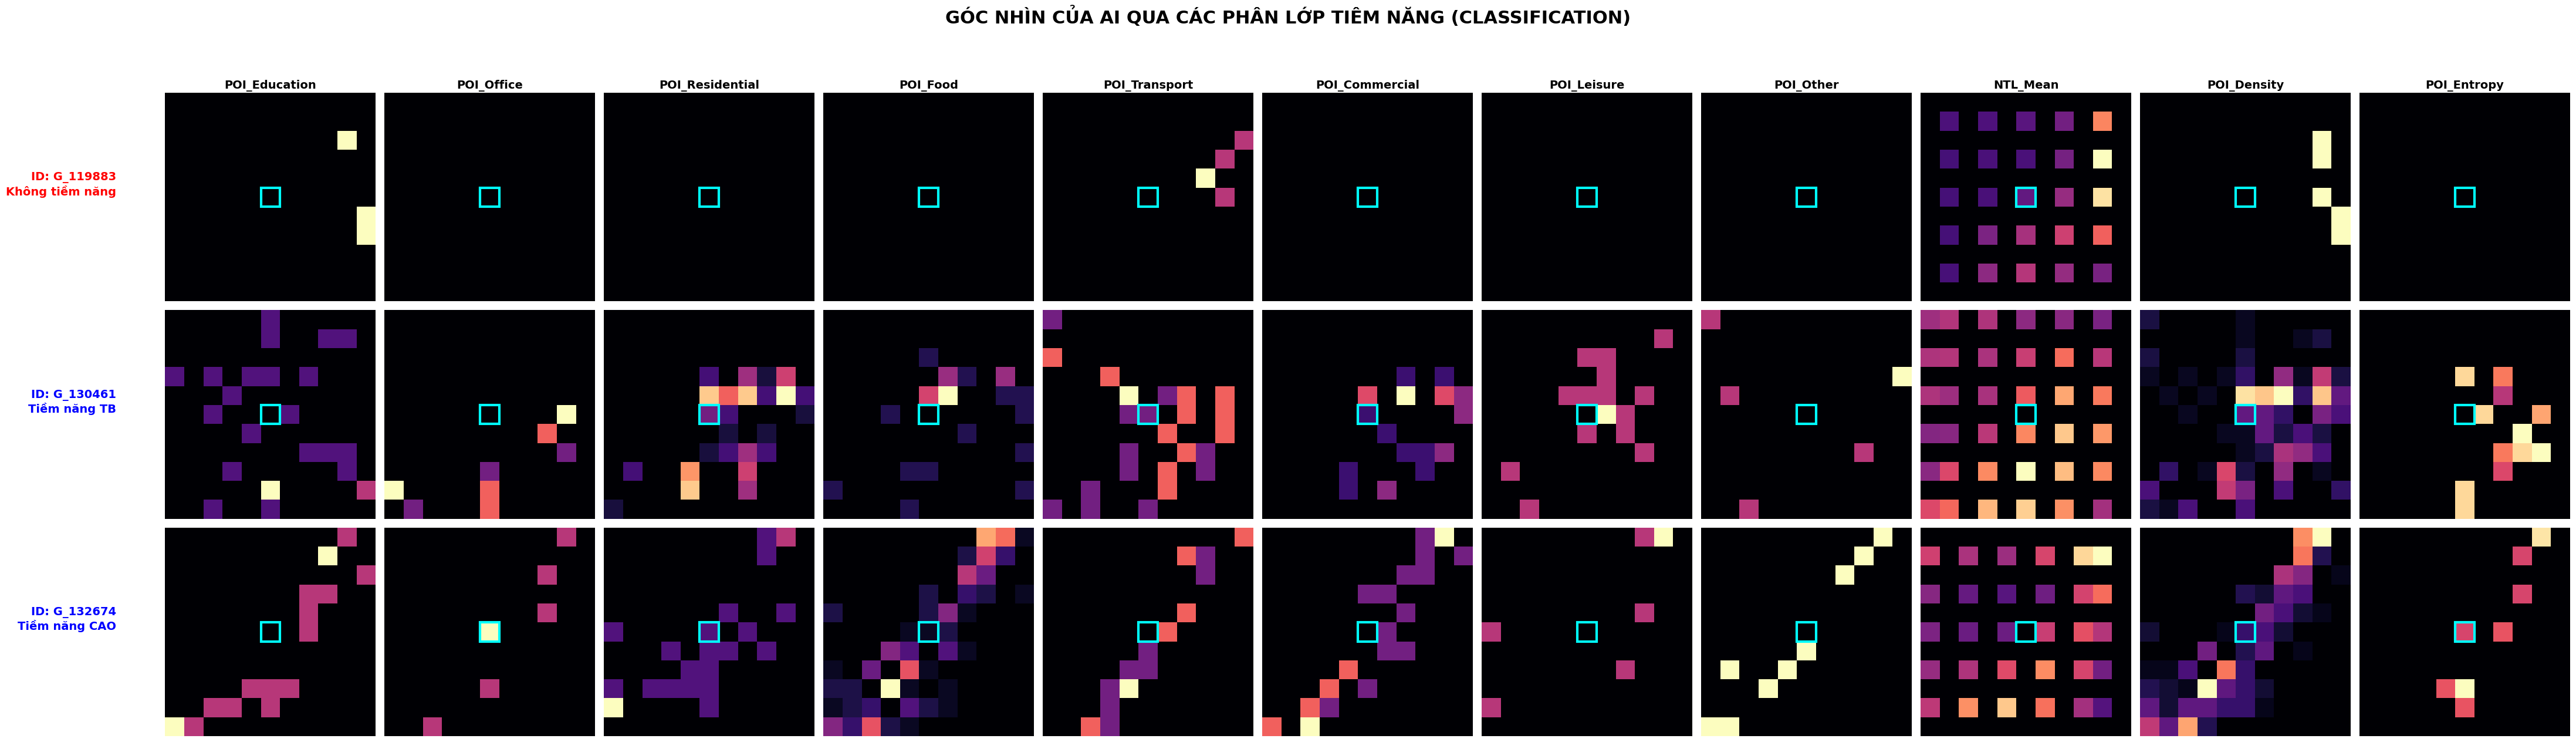

In [ ]:
# 1. Hiển thị mẫu dữ liệu bảng (Cập nhật cột Label)
print("🔍 1. MẪU DỮ LIỆU NHÁNH BẢNG (TABULAR DATA):")
columns_to_show = ['Grid_ID', 'Cafe_Count', 'Total_Reviews', 'V_raw', 'Label']
display(df_tab[columns_to_show].head(10))

# 2. Chuẩn bị mẫu cho 3 Class
print("\n👁️ 2. MẪU DỮ LIỆU NHÁNH KHÔNG GIAN (SPATIAL TENSORS 11x11x11):")

# Định nghĩa tên nhãn để hiển thị cho đẹp
label_names = {0: 'Không tiềm năng', 1: 'Tiềm năng TB', 2: 'Tiềm năng CAO'}
sample_ids = []

# Lấy mẫu từ mỗi class
for lbl in [0, 1, 2]:
    candidates = df_tab[df_tab['Label'] == lbl]
    if not candidates.empty:
        # Lấy ngẫu nhiên 1 mẫu trong mỗi class
        random_sample = candidates.sample(1, random_state=42).iloc[0]
        sample_ids.append((random_sample['Grid_ID'], lbl))

channels_name = ['POI_Education', 'POI_Office', 'POI_Residential',
                 'POI_Food', 'POI_Transport', 'POI_Commercial',
                 'POI_Leisure', 'POI_Other', 'NTL_Mean',
                 'POI_Density', 'POI_Entropy']

# Vẽ biểu đồ
fig, axes = plt.subplots(len(sample_ids), 11, figsize=(44, 4 * len(sample_ids)))

for row_idx, (grid_id, lbl) in enumerate(sample_ids):
    # Giả sử 'tensors' là dictionary chứa ma trận 11x11x5 của bạn
    sample_image = tensors[grid_id]

    for col_idx in range(11):
        ax = axes[row_idx, col_idx]

        # Vẽ Heatmap cho từng channel
        sns.heatmap(sample_image[:, :, col_idx], ax=ax, cmap='magma', cbar=False,
                    xticklabels=False, yticklabels=False)

        # Vẽ khung màu xanh cyan ở giữa
        ax.add_patch(patches.Rectangle((5, 5), 1, 1, fill=False, edgecolor='cyan', lw=3))

        # Tiêu đề cột
        if row_idx == 0:
            ax.set_title(channels_name[col_idx], fontweight='bold', fontsize=14)

        # Nhãn hàng
        if col_idx == 0:
            ax.set_ylabel(f'ID: {grid_id}\n{label_names[lbl]}',
                          fontweight='bold', fontsize=14, rotation=0, labelpad=60, ha='right', color='blue' if lbl > 0 else 'red')

fig.suptitle('GÓC NHÌN CỦA AI QUA CÁC PHÂN LỚP TIÊM NĂNG (CLASSIFICATION)', fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Feature Engineering & Preprocessing**

In [ ]:
# Encode City
label_encoder = LabelEncoder()
df_tab['City_Label'] = label_encoder.fit_transform(df_tab['City'])
vocab_size_city = df_tab['City_Label'].nunique()
print(f"Số thành phố: {vocab_size_city} — {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# Dense features
dense_features = [
    'Center_Lat', 'Center_Lng',
    'POI_Education_log', 'POI_Office_log', 'POI_Residential_capped_log',
    'POI_Food_log', 'POI_Transport_log', 'POI_Commercial_log',
    'POI_Leisure_log', 'POI_Other_log',
    'NTL_log', 'POI_Density', 'POI_Entropy',
]

X_dense  = df_tab[dense_features].values
X_sparse = df_tab[['City_Label']].values
X_img    = np.array([tensors[gid] for gid in df_tab['Grid_ID'].values])
y        = df_tab['Label'].values

print(f"\nShape X_dense  : {X_dense.shape}")
print(f"Shape X_sparse : {X_sparse.shape}")
print(f"Shape X_img    : {X_img.shape}")
print(f"Shape y        : {y.shape}")

Số thành phố: 3 — {'DaNang': np.int64(0), 'HCM': np.int64(1), 'HaNoi': np.int64(2)}

Shape X_dense  : (73974, 13)
Shape X_sparse : (73974, 1)
Shape X_img    : (73974, 11, 11, 11)
Shape y        : (73974,)


In [ ]:
train_dfs, test_dfs = [], []

for city in ['HaNoi', 'HCM', 'DaNang']:
    city_df   = df_tab[df_tab['City'] == city].reset_index(drop=True)
    city_idx  = city_df.index.values
    tr_idx, te_idx = train_test_split(city_idx, test_size=0.2,
                                       random_state=42,
                                       stratify=city_df['Label'])
    train_dfs.append(df_tab[df_tab['City'] == city].iloc[tr_idx])
    test_dfs.append(df_tab[df_tab['City'] == city].iloc[te_idx])

train_df = pd.concat(train_dfs).reset_index(drop=True)
test_df  = pd.concat(test_dfs).reset_index(drop=True)

# Lấy indices từ df_tab gốc
train_mask = df_tab.index.isin(train_df.index)
test_mask  = df_tab.index.isin(test_df.index)

X_d_train_full = X_dense[train_mask]
X_d_test       = X_dense[test_mask]
X_s_train_full = X_sparse[train_mask]
X_s_test       = X_sparse[test_mask]
X_i_train_full = X_img[train_mask]
X_i_test       = X_img[test_mask]
y_train_full   = y[train_mask]
y_test         = y[test_mask]

print(f"Train: {len(y_train_full):,} mẫu")
print(f"Test : {len(y_test):,} mẫu")
print(f"\nPhân bố test theo thành phố:")
for city in ['HaNoi', 'HCM', 'DaNang']:
    n = (test_df['City'] == city).sum()
    print(f"  {city}: {n}")

# Tách val 20% từ train
X_d_train, X_d_val, X_s_train, X_s_val, X_i_train, X_i_val, y_train, y_val = \
    train_test_split(X_d_train_full, X_s_train_full, X_i_train_full, y_train_full,
                     test_size=0.20, random_state=42, stratify=y_train_full)

# UNDERSAMPLE CLASS 0
n_class1         = (y_train == 1).sum()
n_keep_cls0      = n_class1 * 3

idx_cls0         = np.where(y_train == 0)[0]
idx_cls1         = np.where(y_train == 1)[0]
idx_cls2         = np.where(y_train == 2)[0]

np.random.seed(42)
idx_cls0_sampled = np.random.choice(idx_cls0, size=n_keep_cls0, replace=False)
idx_final        = np.concatenate([idx_cls0_sampled, idx_cls1, idx_cls2])
np.random.shuffle(idx_final)

X_d_train = X_d_train[idx_final]
X_s_train = X_s_train[idx_final]
X_i_train = X_i_train[idx_final]
y_train   = y_train[idx_final]

print(f"\nSau undersample:")
for cls in [0, 1, 2]:
    n = (y_train == cls).sum()
    print(f"  Class {cls}: {n} ({n/len(y_train)*100:.1f}%)")

# Scale
scaler    = StandardScaler()
X_d_train = scaler.fit_transform(X_d_train)
X_d_val   = scaler.transform(X_d_val)
X_d_test  = scaler.transform(X_d_test)

# Class weights
class_weights     = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print(f"\nTrain : {len(y_train):,} mẫu")
print(f"Val   : {len(y_val):,} mẫu")
print(f"Test  : {len(y_test):,} mẫu")

print(f"\nClass weights:")
for cls, w in class_weight_dict.items():
    print(f"  Class {cls}: {w:.4f}")

Train: 59,177 mẫu
Test : 14,797 mẫu

Phân bố test theo thành phố:
  HaNoi: 8269
  HCM: 5578
  DaNang: 950

Sau undersample:
  Class 0: 21237 (70.9%)
  Class 1: 7079 (23.6%)
  Class 2: 1628 (5.4%)

Train : 29,944 mẫu
Val   : 11,836 mẫu
Test  : 14,797 mẫu

Class weights:
  Class 0: 0.4700
  Class 1: 1.4100
  Class 2: 6.1310


**Traditional Baseline Models**

In [ ]:
import warnings
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report

from keras.optimizers import Adam
from keras.models import Sequential

from lightgbm import LGBMClassifier, LGBMRegressor

warnings.filterwarnings('ignore')

In [ ]:
X_img_train_flat = X_i_train.reshape(X_i_train.shape[0], -1)
X_img_val_flat   = X_i_val.reshape(X_i_val.shape[0], -1)
X_img_test_flat  = X_i_test.reshape(X_i_test.shape[0], -1)

X_train_trad = np.concatenate([X_d_train, X_s_train, X_img_train_flat], axis=1)
X_val_trad   = np.concatenate([X_d_val,   X_s_val,   X_img_val_flat],   axis=1)
X_test_trad  = np.concatenate([X_d_test,  X_s_test,  X_img_test_flat],  axis=1)

print(f"Kích thước dữ liệu sau khi ghép: {X_train_trad.shape} features")

Kích thước dữ liệu sau khi ghép: (29944, 1345) features


In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score)

def evaluate_classification_model(model_name, y_true, y_pred):
    acc     = accuracy_score(y_true, y_pred)
    f1_mac  = f1_score(y_true, y_pred, average='macro')
    f1_wei  = f1_score(y_true, y_pred, average='weighted')

    print(f"📊 Kết quả {model_name}:")
    print(f"   - Accuracy       : {acc:.4f}")
    print(f"   - F1 Macro       : {f1_mac:.4f}  ← chỉ số chính (paper dùng)")
    print(f"   - F1 Weighted    : {f1_wei:.4f}")
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=['Không TN', 'TN Trung bình', 'TN Cao']))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Không TN', 'TN TB', 'TN Cao'],
                yticklabels=['Không TN', 'TN TB', 'TN Cao'])
    plt.title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.tight_layout()
    plt.show()

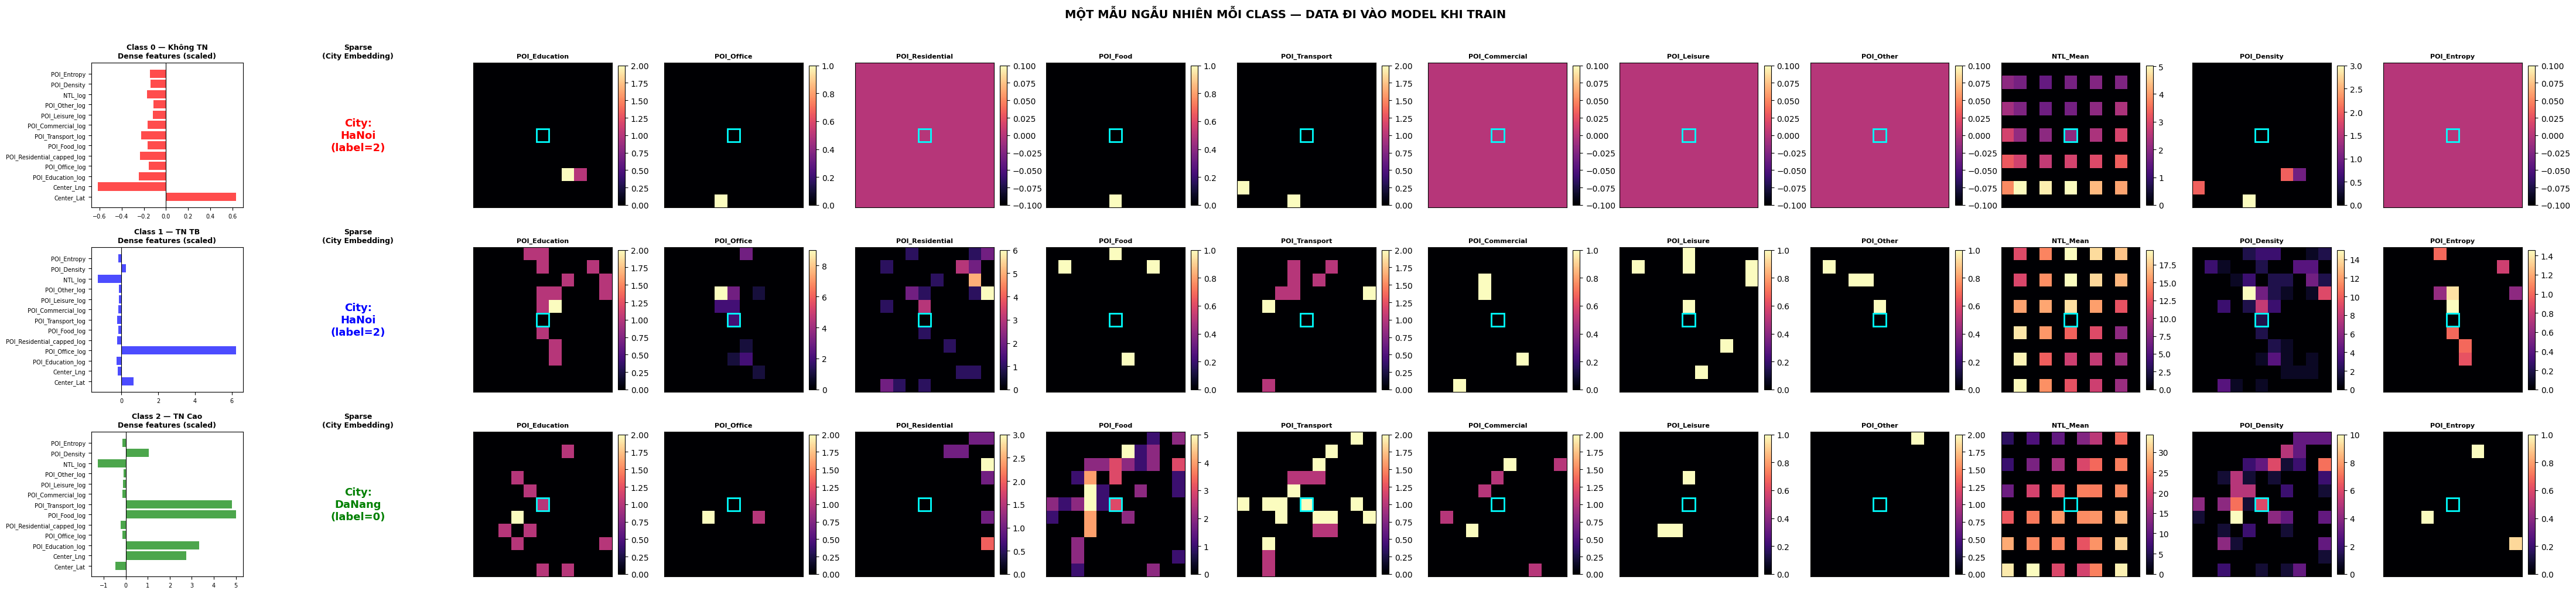


Shape tổng:
  X_d_train : (29944, 13)
  X_s_train : (29944, 1)
  X_i_train : (29944, 11, 11, 11)
  y_train   : (29944,) | unique: (array([0, 1, 2]), array([21237,  7079,  1628]))


In [ ]:
import random

fig, axes = plt.subplots(3, 13, figsize=(44, 10))

channel_names = ['POI_Education', 'POI_Office', 'POI_Residential',
                 'POI_Food', 'POI_Transport', 'POI_Commercial',
                 'POI_Leisure', 'POI_Other', 'NTL_Mean',
                 'POI_Density', 'POI_Entropy']

class_names = {0: 'Class 0 — Không TN', 1: 'Class 1 — TN TB', 2: 'Class 2 — TN Cao'}
colors      = {0: 'red', 1: 'blue', 2: 'green'}

for row, cls in enumerate([0, 1, 2]):
    idx_in_train = np.where(y_train == cls)[0]
    pick         = random.choice(idx_in_train)

    # Cột 0: Dense features
    ax = axes[row, 0]
    feat_vals = X_d_train[pick]
    ax.barh(dense_features, feat_vals, color=colors[cls], alpha=0.7)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{class_names[cls]}\nDense features (scaled)', fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)

    # Cột 1: Sparse
    ax = axes[row, 1]
    city_label = int(X_s_train[pick][0])
    city_name  = label_encoder.inverse_transform([city_label])[0]
    ax.text(0.5, 0.5, f'City:\n{city_name}\n(label={city_label})',
            ha='center', va='center', fontsize=13, fontweight='bold',
            color=colors[cls], transform=ax.transAxes)
    ax.set_title('Sparse\n(City Embedding)', fontsize=9, fontweight='bold')
    ax.axis('off')

    # Cột 2-12: 11 channels
    for ch in range(11):
        ax = axes[row, ch + 2]
        tensor_sample = X_i_train[pick, :, :, ch]
        im = ax.imshow(tensor_sample, cmap='magma', aspect='auto')
        ax.add_patch(plt.Rectangle((4.5, 4.5), 1, 1,
                                    fill=False, edgecolor='cyan', lw=2))
        ax.set_title(f'{channel_names[ch]}', fontsize=8, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('MỘT MẪU NGẪU NHIÊN MỖI CLASS — DATA ĐI VÀO MODEL KHI TRAIN',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Thống kê
print(f"\nShape tổng:")
print(f"  X_d_train : {X_d_train.shape}")
print(f"  X_s_train : {X_s_train.shape}")
print(f"  X_i_train : {X_i_train.shape}")
print(f"  y_train   : {y_train.shape} | unique: {np.unique(y_train, return_counts=True)}")

⏳ Đang huấn luyện Logistic Regression...
📊 Kết quả Logistic Regression:
   - Accuracy       : 0.9165
   - F1 Macro       : 0.7073  ← chỉ số chính (paper dùng)
   - F1 Weighted    : 0.9219

               precision    recall  f1-score   support

     Không TN       0.98      0.96      0.97     12941
TN Trung bình       0.63      0.57      0.60      1356
       TN Cao       0.41      0.82      0.55       500

     accuracy                           0.92     14797
    macro avg       0.68      0.78      0.71     14797
 weighted avg       0.93      0.92      0.92     14797



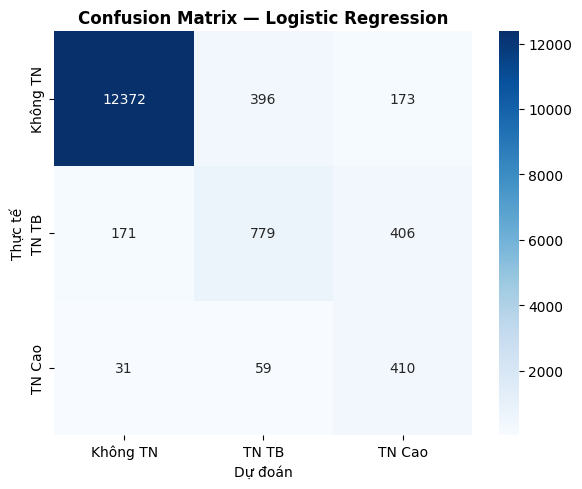

⏳ Đang huấn luyện GBDT (LGBMClassifier)...
📊 Kết quả Gradient Boosting (GBDT):
   - Accuracy       : 0.9670
   - F1 Macro       : 0.8499  ← chỉ số chính (paper dùng)
   - F1 Weighted    : 0.9684

               precision    recall  f1-score   support

     Không TN       0.99      0.99      0.99     12941
TN Trung bình       0.93      0.78      0.85      1356
       TN Cao       0.59      0.90      0.71       500

     accuracy                           0.97     14797
    macro avg       0.84      0.89      0.85     14797
 weighted avg       0.97      0.97      0.97     14797



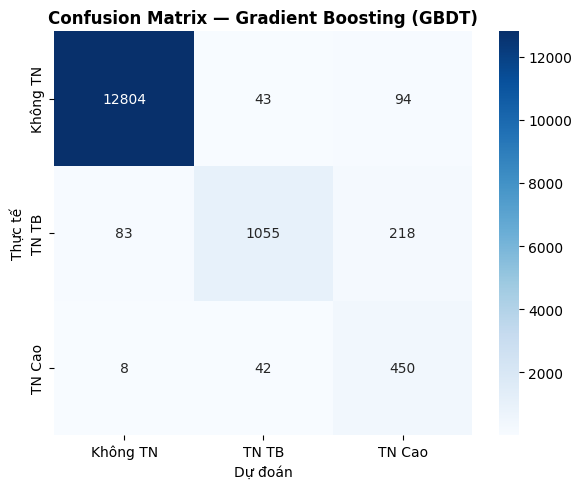

In [ ]:
# ==========================================
# MÔ HÌNH 1: LOGISTIC REGRESSION
# ==========================================
from sklearn.linear_model import LogisticRegression

print("⏳ Đang huấn luyện Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(X_train_trad, y_train)
y_pred_lr = lr_model.predict(X_test_trad)
evaluate_classification_model("Logistic Regression", y_test, y_pred_lr)

# ==========================================
# MÔ HÌNH 2: GBDT
# ==========================================
from lightgbm import LGBMClassifier

print("⏳ Đang huấn luyện GBDT (LGBMClassifier)...")
gbdt_model = LGBMClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
gbdt_model.fit(X_train_trad, y_train)
y_pred_gbdt = gbdt_model.predict(X_test_trad)
evaluate_classification_model("Gradient Boosting (GBDT)", y_test, y_pred_gbdt)

DNN input shape: (29944, 14)
Epoch 1/100
936/936 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6921 - loss: 0.8181 - val_accuracy: 0.7658 - val_loss: 0.5152
Epoch 2/100
936/936 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7355 - loss: 0.6866 - val_accuracy: 0.7892 - val_loss: 0.4305
Epoch 3/100
936/936 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7456 - loss: 0.6637 - val_accuracy: 0.7868 - val_loss: 0.4330
Epoch 4/100
936/936 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7494 - loss: 0.6506 - val_accuracy: 0.7830 - val_loss: 0.4394
Epoch 5/100
936/936 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7507 - loss: 0.6430 - val_accuracy: 0.7856 - val_loss: 0.4418
Epoch 6/100
936/936 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7542 - loss: 0.6412 - val_accuracy: 0.7860 - val_loss: 0.4414
Epoch 7/100
936/936 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7536 - loss: 0.6395 - val_accuracy: 0.7869 - val_loss: 0.4429
Epoch 8/100
936/936 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.

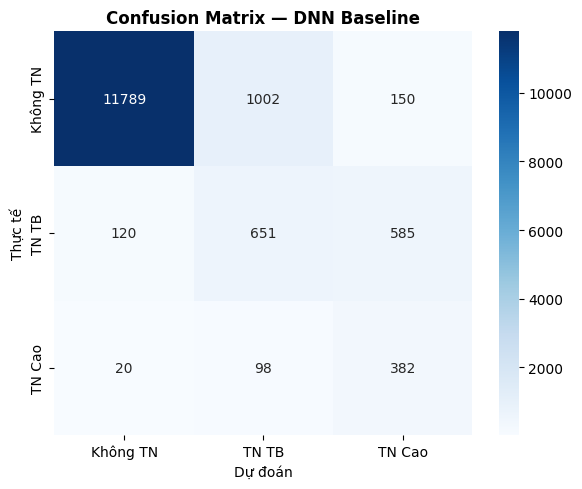

In [ ]:
from keras.models import Sequential
from keras.optimizers import Adam

X_train_dnn = np.concatenate([X_d_train, X_s_train], axis=1)
X_val_dnn   = np.concatenate([X_d_val,   X_s_val],   axis=1)
X_test_dnn  = np.concatenate([X_d_test,  X_s_test],  axis=1)

print(f"DNN input shape: {X_train_dnn.shape}")

dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_dnn.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

dnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=15,
                            restore_best_weights=True, verbose=0)

history_dnn = dnn_model.fit(
    X_train_dnn, y_train,
    validation_data=(X_val_dnn, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

y_pred_dnn = dnn_model.predict(X_test_dnn, verbose=0).argmax(axis=1)
evaluate_classification_model("DNN Baseline", y_test, y_pred_dnn)

⏳ Đang huấn luyện Wide & Deep...
📊 Kết quả Wide & Deep:
   - Accuracy       : 0.8698
   - F1 Macro       : 0.6273  ← chỉ số chính (paper dùng)
   - F1 Weighted    : 0.8870

               precision    recall  f1-score   support

     Không TN       0.99      0.91      0.95     12941
TN Trung bình       0.39      0.52      0.44      1356
       TN Cao       0.36      0.78      0.49       500

     accuracy                           0.87     14797
    macro avg       0.58      0.74      0.63     14797
 weighted avg       0.91      0.87      0.89     14797



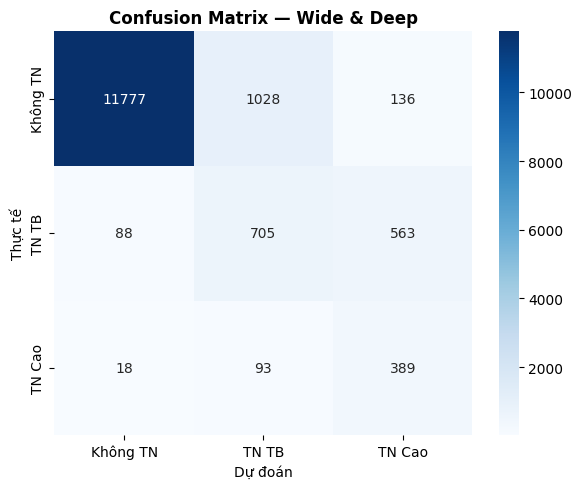

In [ ]:
from keras.optimizers import Adam

# ==========================================
# MÔ HÌNH 3: WIDE & DEEP
# ==========================================
print("⏳ Đang huấn luyện Wide & Deep...")

input_wd  = Input(shape=(X_train_dnn.shape[1],))
wide      = Dense(16, activation='linear', name="Wide")(input_wd)
deep_wd   = Dense(128, activation='relu')(input_wd)
deep_wd   = BatchNormalization()(deep_wd)
deep_wd   = Dropout(0.3)(deep_wd)
deep_wd   = Dense(64, activation='relu')(deep_wd)
deep_wd   = BatchNormalization()(deep_wd)
deep_wd   = Dropout(0.3)(deep_wd)
deep_wd   = Dense(32, activation='relu')(deep_wd)
concat_wd = Concatenate()([wide, deep_wd])
output_wd = Dense(3, activation='softmax')(concat_wd)

wd_model  = Model(inputs=input_wd, outputs=output_wd)
wd_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_wd = EarlyStopping(monitor='val_loss', patience=15,
                               restore_best_weights=True, verbose=0)

wd_model.fit(
    X_train_dnn, y_train,
    validation_data=(X_val_dnn, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop_wd],
    verbose=0
)

y_pred_wd = wd_model.predict(X_test_dnn, verbose=0).argmax(axis=1)
evaluate_classification_model("Wide & Deep", y_test, y_pred_wd)

**The Proposed Model**

In [ ]:
import time
import tensorflow as tf
import keras.backend as K
from sklearn.metrics import classification_report, confusion_matrix
from keras.layers import Input, Dense, Embedding, Flatten, Multiply, GlobalAveragePooling2D, Reshape, Lambda

In [ ]:
tf.keras.backend.clear_session()

**1. Embedding Layers**

In [ ]:
EMBEDDING_DIM = 16

input_dense   = Input(shape=(X_d_train.shape[1],), name="Input_Dense")
input_sparse  = Input(shape=(1,),                  name="Input_Sparse")
input_spatial = Input(shape=(11, 11, 11), name="Input_Spatial")

field_emb = Embedding(input_dim=vocab_size_city, output_dim=EMBEDDING_DIM, name="Field_Embedding")(input_sparse)
field_emb = Flatten(name="Field_Embedding_Flat")(field_emb)

channel_pool           = GlobalAveragePooling2D(name="Channel_Pooling")(input_spatial)
channel_alpha          = Dense(11, activation='softmax', name="Channel_Attention_Weights")(channel_pool)
channel_alpha_reshaped = Reshape((1, 1, 11))(channel_alpha)
X_sc = Multiply(name="Apply_Channel_Attention")([input_spatial, channel_alpha_reshaped])

spatial_squeeze        = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True), name="Spatial_Squeeze")(X_sc)
spatial_flat           = Flatten()(spatial_squeeze)
spatial_gamma          = Dense(121, activation='softmax', name="Spatial_Attention_Weights")(spatial_flat)
spatial_gamma_reshaped = Reshape((11, 11, 1))(spatial_gamma)
X_scs                  = Multiply(name="Apply_Spatial_Attention")([X_sc, spatial_gamma_reshaped])

spatial_flat_final = Flatten()(X_scs)
spatial_emb        = Dense(EMBEDDING_DIM * 11, activation='relu', name="Spatial_Embedding_Output")(spatial_flat_final)

print(f"   - Đầu ra của Field Embedding  : {field_emb.shape}")
print(f"   - Đầu ra của Spatial Embedding: {spatial_emb.shape}")
print(f"   - Đầu vào Dense (giữ nguyên)  : {input_dense.shape}")

   - Đầu ra của Field Embedding  : (None, 16)
   - Đầu ra của Spatial Embedding: (None, 176)
   - Đầu vào Dense (giữ nguyên)  : (None, 13)


**2. Cross Network**

In [ ]:
class CrossLayer(Layer):
    def __init__(self, **kwargs):
        super(CrossLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        dim = int(input_shape[0][-1])
        self.w = self.add_weight(shape=(dim, 1), initializer='glorot_uniform', trainable=True, name='cross_w')
        self.b = self.add_weight(shape=(dim,), initializer='zeros', trainable=True, name='cross_b')
        super(CrossLayer, self).build(input_shape)

    def call(self, inputs):
        x0, xl = inputs
        xl_w = tf.matmul(xl, self.w)
        return x0 * xl_w + self.b + xl

In [ ]:
# Ghép các Embeddings (Sparse) và Input Dense lại thành vector x0
x0 = Concatenate(name="CrossNet_Input")([input_dense, field_emb, spatial_emb])

# ------------------------------------------
# XÂY DỰNG 4 LỚP TƯƠNG TÁC CHÉO
# ------------------------------------------
cross_1   = CrossLayer(name="Cross_Layer_1")([x0, x0])
cross_2   = CrossLayer(name="Cross_Layer_2")([x0, cross_1])
cross_3   = CrossLayer(name="Cross_Layer_3")([x0, cross_2])
cross_out = CrossLayer(name="Cross_Layer_4")([x0, cross_3])

print(f"   - Hình dáng vector x0 đầu vào: {x0.shape}")
print(f"   - Đầu ra của Mạng Chéo       : {cross_out.shape}")

   - Hình dáng vector x0 đầu vào: (None, 205)
   - Đầu ra của Mạng Chéo       : (None, 205)


**3. Deep Network**

In [ ]:
# 1. XÂY DỰNG MẠNG SÂU (DEEP NETWORK)
deep      = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x0)
deep      = BatchNormalization()(deep)
deep      = Dropout(0.3)(deep)

deep      = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(deep)
deep      = BatchNormalization()(deep)
deep      = Dropout(0.3)(deep)

deep_out  = Dense(32, activation='relu')(deep)

# 2. THÀNH PHẦN TUYẾN TÍNH (WIDE / LINEAR COMPONENT)
wide_out  = Dense(32, activation='linear', name="Wide_Linear")(x0)

# 3. PROJECT CROSS OUTPUT VỀ CÙNG SIZE
cross_proj = Dense(32, activation='relu', name="Cross_Projection")(cross_out)

# 4. LỚP KẾT HỢP — thay cross_out thành cross_proj
concat_final = Concatenate(name="Combination_Layer")([wide_out, cross_proj, deep_out])

dense_final  = Dense(32, activation='relu')(concat_final)
dense_final  = BatchNormalization()(dense_final)
dense_final  = Dropout(0.3)(dense_final)

# 5. OUTPUT — 3 classes
output = Dense(3, activation='softmax', name="Output_Score")(dense_final)

deepstore_model = Model(
    inputs=[input_dense, input_sparse, input_spatial],
    outputs=output
)

deepstore_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deepstore_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Spatial       │ (None, 11, 11,    │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Channel_Pooling     │ (None, 11)        │          0 │ Input_Spatial[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Channel_Attention_… │ (None, 11)        │        132 │ Channel_Pooling[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 11)  │          0 │ Channel_Attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Apply_Channel_Atte… │ (None, 11, 11,    │          0 │ Input_Spatial[0]… │
│ (Multiply)          │ 11)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Spatial_Squeeze     │ (None, 11, 11, 1) │          0 │ Apply_Channel_At… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 121)       │          0 │ Spatial_Squeeze[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Spatial_Attention_… │ (None, 121)       │     14,762 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 11, 11, 1) │          0 │ Spatial_Attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Sparse        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Apply_Spatial_Atte… │ (None, 11, 11,    │          0 │ Apply_Channel_At… │
│ (Multiply)          │ 11)               │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Field_Embedding     │ (None, 1, 16)     │         48 │ Input_Sparse[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1331)      │          0 │ Apply_Spatial_At… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Dense         │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Field_Embedding_Fl… │ (None, 16)        │          0 │ Field_Embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Spatial_Embedding_… │ (None, 176)       │    234,432 │ flatten_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CrossNet_Input      │ (None, 205)       │          0 │ Input_Dense[0][0… │
│ (Concatenate)       │                   │            │ Field_Embedding_… │
│                     │                   │            │ Spatial_Embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     26,368 │ CrossNet_Input[0

 Total params: 305,001 (1.16 MB)

 Trainable params: 304,553 (1.16 MB)

 Non-trainable params: 448 (1.75 KB)

⏳ Đang huấn luyện DCN...
📊 Kết quả DCN:
   - Accuracy       : 0.8673
   - F1 Macro       : 0.6117  ← chỉ số chính (paper dùng)
   - F1 Weighted    : 0.8844

               precision    recall  f1-score   support

     Không TN       0.99      0.91      0.95     12941
TN Trung bình       0.38      0.47      0.42      1356
       TN Cao       0.33      0.79      0.47       500

     accuracy                           0.87     14797
    macro avg       0.57      0.72      0.61     14797
 weighted avg       0.91      0.87      0.88     14797



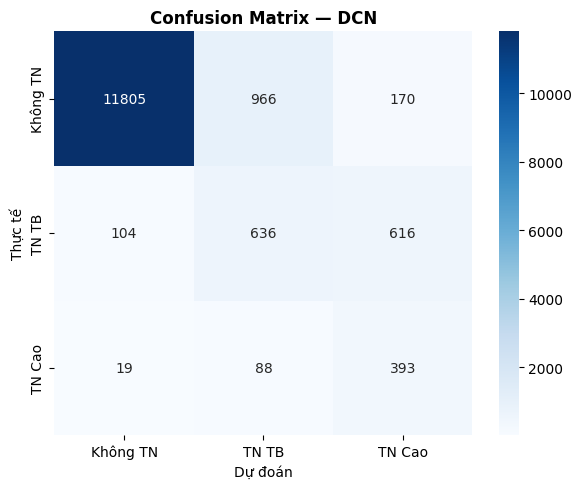

In [ ]:
# ==========================================
# MÔ HÌNH 4: DCN (Deep & Cross Network)
# ==========================================
print("⏳ Đang huấn luyện DCN...")

input_dcn = Input(shape=(X_train_dnn.shape[1],))

# Cross Network — dùng lại CrossLayer đã định nghĩa
x0_dcn    = input_dcn
cross_dcn_1 = CrossLayer(name="DCN_Cross_1")([x0_dcn, x0_dcn])
cross_dcn_2 = CrossLayer(name="DCN_Cross_2")([x0_dcn, cross_dcn_1])
cross_dcn_3 = CrossLayer(name="DCN_Cross_3")([x0_dcn, cross_dcn_2])
cross_dcn_out = CrossLayer(name="DCN_Cross_4")([x0_dcn, cross_dcn_3])

# Deep Network
deep_dcn  = Dense(128, activation='relu')(input_dcn)
deep_dcn  = BatchNormalization()(deep_dcn)
deep_dcn  = Dropout(0.3)(deep_dcn)
deep_dcn  = Dense(64, activation='relu')(deep_dcn)
deep_dcn  = BatchNormalization()(deep_dcn)
deep_dcn  = Dropout(0.3)(deep_dcn)
deep_dcn_out = Dense(32, activation='relu')(deep_dcn)

# Combination
cross_dcn_proj = Dense(32, activation='relu')(cross_dcn_out)
concat_dcn     = Concatenate()([cross_dcn_proj, deep_dcn_out])
dense_dcn      = Dense(32, activation='relu')(concat_dcn)
dense_dcn      = BatchNormalization()(dense_dcn)
dense_dcn      = Dropout(0.3)(dense_dcn)
output_dcn     = Dense(3, activation='softmax')(dense_dcn)

dcn_model = Model(inputs=input_dcn, outputs=output_dcn)
dcn_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_dcn = EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0)

dcn_model.fit(
    X_train_dnn, y_train,
    validation_data=(X_val_dnn, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop_dcn],
    verbose=0
)

y_pred_dcn = dcn_model.predict(X_test_dnn, verbose=0).argmax(axis=1)
evaluate_classification_model("DCN", y_test, y_pred_dcn)

**Training & Evaluation**

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10,    # 15→10
                            restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1)

history_ds = deepstore_model.fit(
    x=[X_d_train, X_s_train, X_i_train],
    y=y_train,
    validation_data=([X_d_val, X_s_val, X_i_val], y_val),
    epochs=150,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.5637 - loss: 1.4144 - val_accuracy: 0.7573 - val_loss: 1.0362 - learning_rate: 5.0000e-04
Epoch 2/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7026 - loss: 1.0618 - val_accuracy: 0.8217 - val_loss: 0.8211 - learning_rate: 5.0000e-04
Epoch 3/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7621 - loss: 0.9228 - val_accuracy: 0.8373 - val_loss: 0.7087 - learning_rate: 5.0000e-04
Epoch 4/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7929 - loss: 0.8376 - val_accuracy: 0.8536 - val_loss: 0.6073 - learning_rate: 5.0000e-04
Epoch 5/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8147 - loss: 0.7690 - val_accuracy: 0.8641 - val_loss: 0.5277 - learning_rate: 5.0000e-04
Epoch 6/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8359 - loss: 0.7286 - val_accuracy: 0.8750 - val_loss: 0.4975 - learning_rate: 5.0000e-04
Epoch 7/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - a

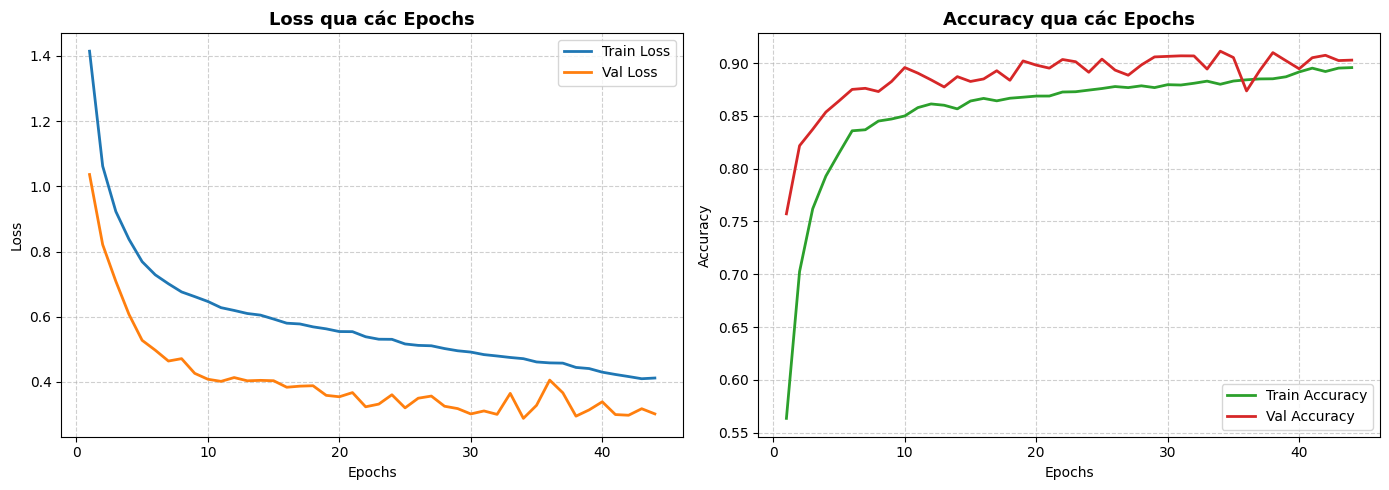

In [ ]:
train_loss = history_ds.history['loss']
val_loss   = history_ds.history['val_loss']
train_acc  = history_ds.history['accuracy']
val_acc    = history_ds.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(epochs_range, val_loss,   label='Val Loss',   color='#ff7f0e', linewidth=2)
plt.title('Loss qua các Epochs', fontsize=13, fontweight='bold')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Train Accuracy', color='#2ca02c', linewidth=2)
plt.plot(epochs_range, val_acc,   label='Val Accuracy',   color='#d62728', linewidth=2)
plt.title('Accuracy qua các Epochs', fontsize=13, fontweight='bold')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

📊 Kết quả DeepStore:
   - Accuracy       : 0.9381
   - F1 Macro       : 0.7365  ← chỉ số chính (paper dùng)
   - F1 Weighted    : 0.9418

               precision    recall  f1-score   support

     Không TN       0.99      0.98      0.98     12941
TN Trung bình       0.84      0.57      0.68      1356
       TN Cao       0.40      0.85      0.55       500

     accuracy                           0.94     14797
    macro avg       0.74      0.80      0.74     14797
 weighted avg       0.96      0.94      0.94     14797



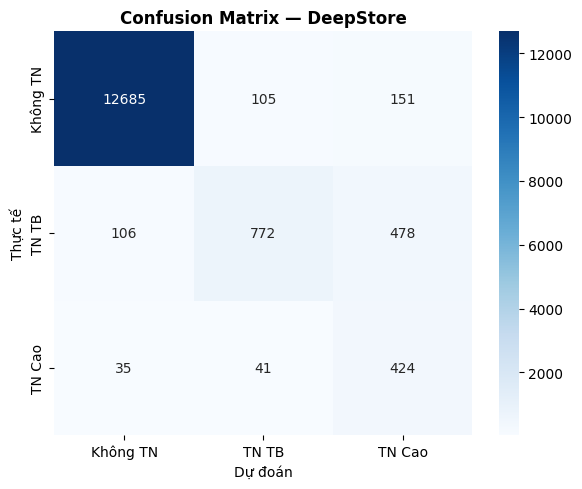

In [ ]:
# 1. Dự đoán điểm số
y_pred_ds = deepstore_model.predict(
    [X_d_test, X_s_test, X_i_test], verbose=0
).argmax(axis=1)
residuals = y_test - y_pred_ds

# 2. Tính toán các chỉ số
evaluate_classification_model("DeepStore", y_test, y_pred_ds)

In [ ]:
# Kiểm tra val loss vs train loss cuối cùng
print("Train Loss cuối:", history_ds.history['loss'][-1])
print("Val Loss cuối  :", history_ds.history['val_loss'][-1])
print("Epochs đã chạy :", len(history_ds.history['loss']))

# Kiểm tra val set phân bố nhãn
print("\nPhân bố nhãn Val:")
for cls in [0, 1, 2]:
    n = (y_val == cls).sum()
    print(f"  Class {cls}: {n} ({n/len(y_val)*100:.1f}%)")

# DeepStore predict trên val
y_pred_val = deepstore_model.predict(
    [X_d_val, X_s_val, X_i_val], verbose=0
).argmax(axis=1)

print("\nKết quả trên Val:")
print(f"  F1 Macro: {f1_score(y_val, y_pred_val, average='macro'):.4f}")
print(classification_report(y_val, y_pred_val,
      target_names=['Không TN', 'TN TB', 'TN Cao']))

Train Loss cuối: 0.41210538148880005
Val Loss cuối  : 0.3021305501461029
Epochs đã chạy : 44

Phân bố nhãn Val:
  Class 0: 9659 (81.6%)
  Class 1: 1770 (15.0%)
  Class 2: 407 (3.4%)

Kết quả trên Val:
  F1 Macro: 0.7056
              precision    recall  f1-score   support

    Không TN       0.98      0.97      0.98      9659
       TN TB       0.82      0.65      0.72      1770
      TN Cao       0.30      0.68      0.42       407

    accuracy                           0.91     11836
   macro avg       0.70      0.77      0.71     11836
weighted avg       0.94      0.91      0.92     11836



In [ ]:
results = {
    'Logistic Regression': y_pred_lr,
    # 'GBDT'               : y_pred_gbdt,
    'DNN Baseline'       : y_pred_dnn,
    'Wide & Deep'        : y_pred_wd,
    'DCN'                : y_pred_dcn,
    'DeepStore'          : y_pred_ds,
}

print(f"{'Model':<25} {'Accuracy':>10} {'F1 Macro':>10} {'F1 Weighted':>12}")
print("-" * 60)
for name, y_pred in results.items():
    acc    = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_wei = f1_score(y_test, y_pred, average='weighted')
    print(f"{name:<25} {acc:>10.4f} {f1_mac:>10.4f} {f1_wei:>12.4f}")

Model                       Accuracy   F1 Macro  F1 Weighted
------------------------------------------------------------
Logistic Regression           0.9165     0.7073       0.9219
DNN Baseline                  0.8665     0.6132       0.8835
Wide & Deep                   0.8698     0.6273       0.8870
DCN                           0.8673     0.6117       0.8844
DeepStore                     0.9381     0.7365       0.9418


In [ ]:
output_df = df_tab[['Grid_ID', 'City', 'Center_Lat', 'Center_Lng', 'Label']].copy()
output_df['opportunity_score'] = df_tab['Label']

# Export ra Google Drive
output_df.to_csv('/content/drive/MyDrive/SmartSite/grid_predictions.csv', index=False)
print(f"Exported {len(output_df)} rows")
print(output_df['Label'].value_counts())

Exported 73974 rows
Label
0    57154
1    13454
2     3366
Name: count, dtype: int64
